# 🎵 Analiza Glasbenih Trendov na Platformi Spotify

## Glavni Raziskovalni Problem

> **Kateri zvočni in žanrski vzorci opredeljujejo glasbene trende na Spotifyju in kako so ti vzorci povezani s priljubljenostjo skladb?**

---

## 📋 Raziskovalna Vprašanja

Ta analiza sistematično odgovarja na naslednja raziskovalna vprašanja:

| # | Raziskovalno Vprašanje | Sekcija | Metode |
|---|------------------------|---------|--------|
| **RV1** | Katere zvočne značilnosti najbolj opisujejo sodobne glasbene trende? | Sekcija 2 | Opisna statistika, distribucije |
| **RV2** | Kako so zvočne značilnosti med seboj povezane? | Sekcija 3 | Korelacijska analiza, heatmap |
| **RV3** | Ali obstajajo značilni tipi skladb (glasbeni profili)? | Sekcija 4 | K-Means clustering, PCA |
| **RV4** | Kako se glasbeni profili razlikujejo glede na priljubljenost? | Sekcija 5 | Primerjava clustrov, statistični testi |
| **RV5** | Ali lahko napovemo priljubljenost skladb? | Sekcija 6 | Random Forest, regresija |
| **RV6** | Kako se trendi razlikujejo med državami/regijami? | Del 2 (regional) | Top-50 analiza |

---

## 📊 Podatkovni Viri

| Vir | Tip | Vsebina | Velikost |
|-----|-----|---------|----------|
| **Kaggle CSV** | Statični | Audio features, žanri | 114.000+ skladb |
| **Top-50 CSV** | Časovni | Lestvice po državah | 10 držav |

### Zvočne Značilnosti (Audio Features)

| Atribut | Opis | Razpon |
|---------|------|--------|
| `danceability` | Primernost za ples | 0.0 - 1.0 |
| `energy` | Intenzivnost in aktivnost | 0.0 - 1.0 |
| `valence` | Pozitivnost/veselost | 0.0 - 1.0 |
| `acousticness` | Akustična narava | 0.0 - 1.0 |
| `speechiness` | Prisotnost govora | 0.0 - 1.0 |
| `instrumentalness` | Instrumentalna narava | 0.0 - 1.0 |
| `liveness` | Prisotnost občinstva | 0.0 - 1.0 |
| `loudness` | Glasnost v dB | -60 - 0 |
| `tempo` | BPM | 40 - 220 |
| `popularity` | Priljubljenost | 0 - 100 |

---

## 1. Priprava Okolja in Podatkov

Uvoz knjižnic in nalaganje dataseta.

In [1]:
# Osnovne knjižnice
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Vizualizacija
import matplotlib.pyplot as plt
import seaborn as sns

# Statistična analiza
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway

# Strojno učenje
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.feature_selection import SelectKBest, f_classif

# Spotify API
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Nastavitve vizualizacije
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✅ Vse knjižnice uspešno uvožene!")

# =====================================================
# NALAGANJE PODATKOV
# =====================================================
print("\n📁 NALAGANJE PODATKOV...")
print("-" * 50)

# Naloži glavni dataset
df = pd.read_csv('../data/dataset.csv')

print(f"✅ Naložen dataset: {len(df):,} skladb, {df.shape[1]} stolpcev")
print(f"   Žanrov: {df['track_genre'].nunique()}")
print(f"   Izvajalcev: {df['artists'].nunique():,}")

✅ Vse knjižnice uspešno uvožene!

📁 NALAGANJE PODATKOV...
--------------------------------------------------
✅ Naložen dataset: 114,000 skladb, 21 stolpcev
   Žanrov: 114
   Izvajalcev: 31,437


---

# 🔬 SEKCIJA 2: Raziskovalno Vprašanje 1

## RV1: Katere zvočne značilnosti najbolj opisujejo sodobne glasbene trende na Spotifyju?

**Cilj:** Identificirati ključne zvočne značilnosti, ki definirajo trenutne glasbene trende.

**Metode:**
- Opisna statistika (povprečje, mediana, std)
- Porazdelitve vrednosti
- Primerjava med žanri

In [2]:
# =====================================================
# 2.1 PREGLED ZVOČNIH ZNAČILNOSTI PO ŽANRIH
# =====================================================
print("🎭 PREGLED ŽANROV V DATASETU")
print("=" * 70)

# Definiraj zvočne značilnosti
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'loudness']

# Osnovne statistike
n_total_tracks = len(df)
n_genres = df['track_genre'].nunique()
genre_counts = df['track_genre'].value_counts()

print(f"\n📊 Osnovne Statistike:")
print(f"   Skupaj skladb: {n_total_tracks:,}")
print(f"   Število žanrov: {n_genres}")
print(f"   Skladb na žanr: {n_total_tracks/n_genres:.0f} (uravnotežen dataset)")

# Izračunaj povprečne zvočne značilnosti za vsak žanr
genre_profiles = df.groupby('track_genre')[audio_features].mean()

# Prikaži značilnosti za nekaj žanrov
print(f"\n🎵 POVPREČNE ZVOČNE ZNAČILNOSTI (5 naključnih žanrov):")
print("-" * 70)
sample_genres = genre_profiles.sample(5)
print(sample_genres.round(3).to_string())

# Poišči ekstremne žanre
print(f"\n🏆 EKSTREMNI ŽANRI PO ZNAČILNOSTIH:")
print("-" * 70)
for feature in ['danceability', 'energy', 'valence', 'acousticness']:
    max_genre = genre_profiles[feature].idxmax()
    min_genre = genre_profiles[feature].idxmin()
    print(f"{feature:15} | MAX: {max_genre:20} ({genre_profiles.loc[max_genre, feature]:.3f})")
    print(f"{'':15} | MIN: {min_genre:20} ({genre_profiles.loc[min_genre, feature]:.3f})")
    print()

# Top 15 žanrov za nadaljnjo analizo
top_genres = genre_counts.head(15).index.tolist()
df_top_genres = df[df['track_genre'].isin(top_genres)]

print(f"✅ Pripravljeno {len(top_genres)} žanrov za nadaljnjo analizo")

🎭 PREGLED ŽANROV V DATASETU

📊 Osnovne Statistike:
   Skupaj skladb: 114,000
   Število žanrov: 114
   Skladb na žanr: 1000 (uravnotežen dataset)

🎵 POVPREČNE ZVOČNE ZNAČILNOSTI (5 naključnih žanrov):
----------------------------------------------------------------------
                danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence    tempo  loudness
track_genre                                                                                                            
detroit-techno         0.723   0.711        0.073         0.066             0.700     0.155    0.469  126.592   -11.086
dubstep                0.518   0.759        0.090         0.114             0.093     0.200    0.272  133.632    -5.063
happy                  0.553   0.911        0.120         0.057             0.264     0.284    0.327  152.909    -5.417
indian                 0.592   0.567        0.072         0.485             0.039     0.173    0.463  116.143    -8.851
world-mu

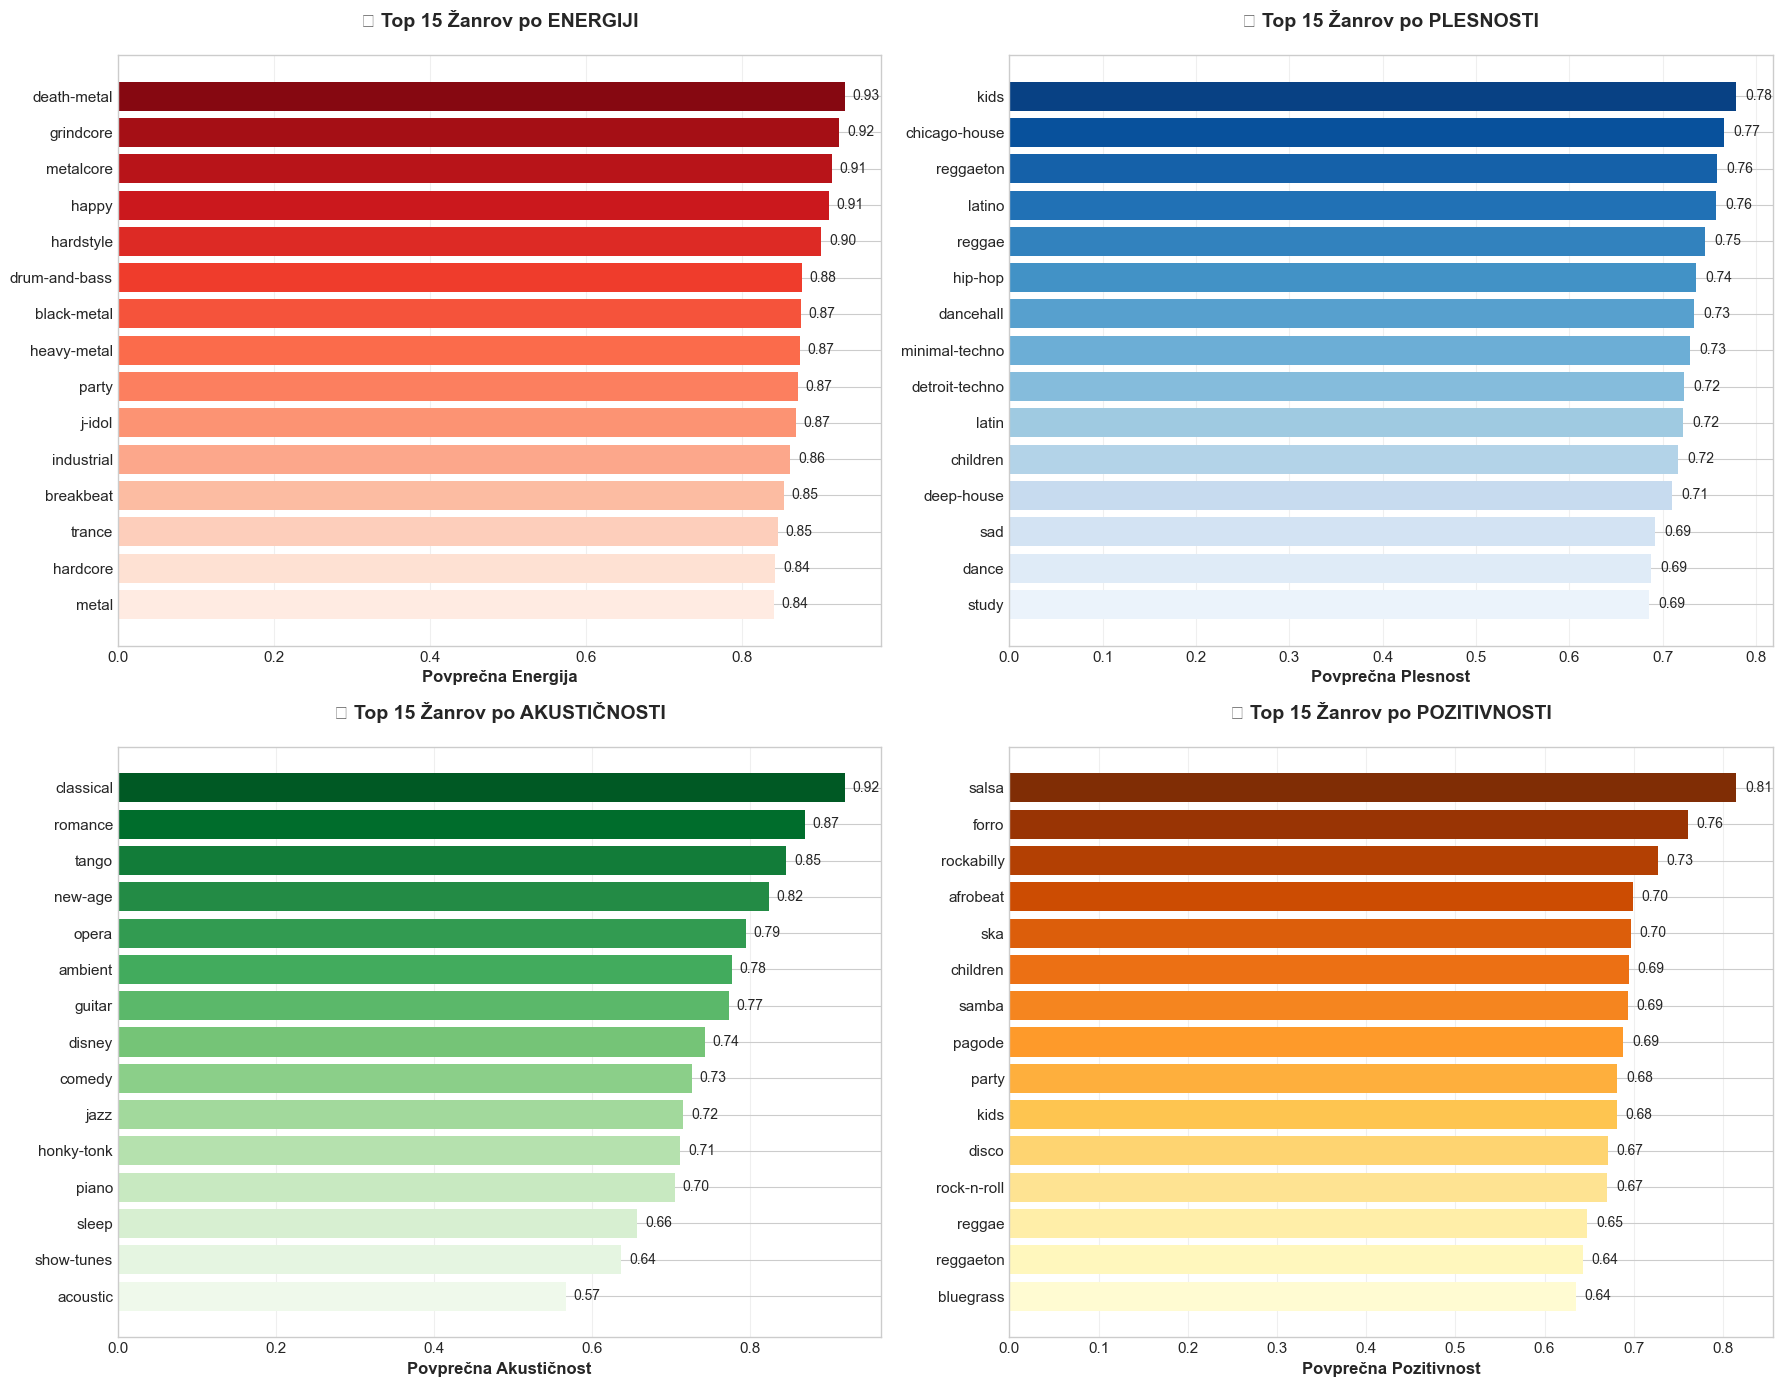


💡 Vsak graf prikazuje 15 žanrov z najvišjimi vrednostmi za to značilnost


In [3]:
# =====================================================
# VIZUALIZACIJA ZVOČNIH ZNAČILNOSTI PO ŽANRIH
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Top 15 žanrov po ENERGIJI
top_energy = genre_profiles['energy'].sort_values(ascending=False).head(15)
ax1 = axes[0, 0]
colors = sns.color_palette("Reds_r", 15)
ax1.barh(range(len(top_energy)), top_energy.values, color=colors)
ax1.set_yticks(range(len(top_energy)))
ax1.set_yticklabels(top_energy.index)
ax1.set_xlabel('Povprečna Energija', fontsize=12, fontweight='bold')
ax1.set_title('⚡ Top 15 Žanrov po ENERGIJI', fontsize=14, fontweight='bold', pad=20)
ax1.invert_yaxis()
for i, v in enumerate(top_energy.values):
    ax1.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# 2. Top 15 žanrov po PLESNOSTI (danceability)
top_dance = genre_profiles['danceability'].sort_values(ascending=False).head(15)
ax2 = axes[0, 1]
colors2 = sns.color_palette("Blues_r", 15)
ax2.barh(range(len(top_dance)), top_dance.values, color=colors2)
ax2.set_yticks(range(len(top_dance)))
ax2.set_yticklabels(top_dance.index)
ax2.set_xlabel('Povprečna Plesnost', fontsize=12, fontweight='bold')
ax2.set_title('💃 Top 15 Žanrov po PLESNOSTI', fontsize=14, fontweight='bold', pad=20)
ax2.invert_yaxis()
for i, v in enumerate(top_dance.values):
    ax2.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# 3. Top 15 žanrov po AKUSTIČNOSTI
top_acoustic = genre_profiles['acousticness'].sort_values(ascending=False).head(15)
ax3 = axes[1, 0]
colors3 = sns.color_palette("Greens_r", 15)
ax3.barh(range(len(top_acoustic)), top_acoustic.values, color=colors3)
ax3.set_yticks(range(len(top_acoustic)))
ax3.set_yticklabels(top_acoustic.index)
ax3.set_xlabel('Povprečna Akustičnost', fontsize=12, fontweight='bold')
ax3.set_title('🎸 Top 15 Žanrov po AKUSTIČNOSTI', fontsize=14, fontweight='bold', pad=20)
ax3.invert_yaxis()
for i, v in enumerate(top_acoustic.values):
    ax3.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
ax3.grid(axis='x', alpha=0.3)

# 4. Top 15 žanrov po POZITIVNOSTI (valence)
top_valence = genre_profiles['valence'].sort_values(ascending=False).head(15)
ax4 = axes[1, 1]
colors4 = sns.color_palette("YlOrBr_r", 15)
ax4.barh(range(len(top_valence)), top_valence.values, color=colors4)
ax4.set_yticks(range(len(top_valence)))
ax4.set_yticklabels(top_valence.index)
ax4.set_xlabel('Povprečna Pozitivnost', fontsize=12, fontweight='bold')
ax4.set_title('😊 Top 15 Žanrov po POZITIVNOSTI', fontsize=14, fontweight='bold', pad=20)
ax4.invert_yaxis()
for i, v in enumerate(top_valence.values):
    ax4.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/genre_audio_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Vsak graf prikazuje 15 žanrov z najvišjimi vrednostmi za to značilnost")

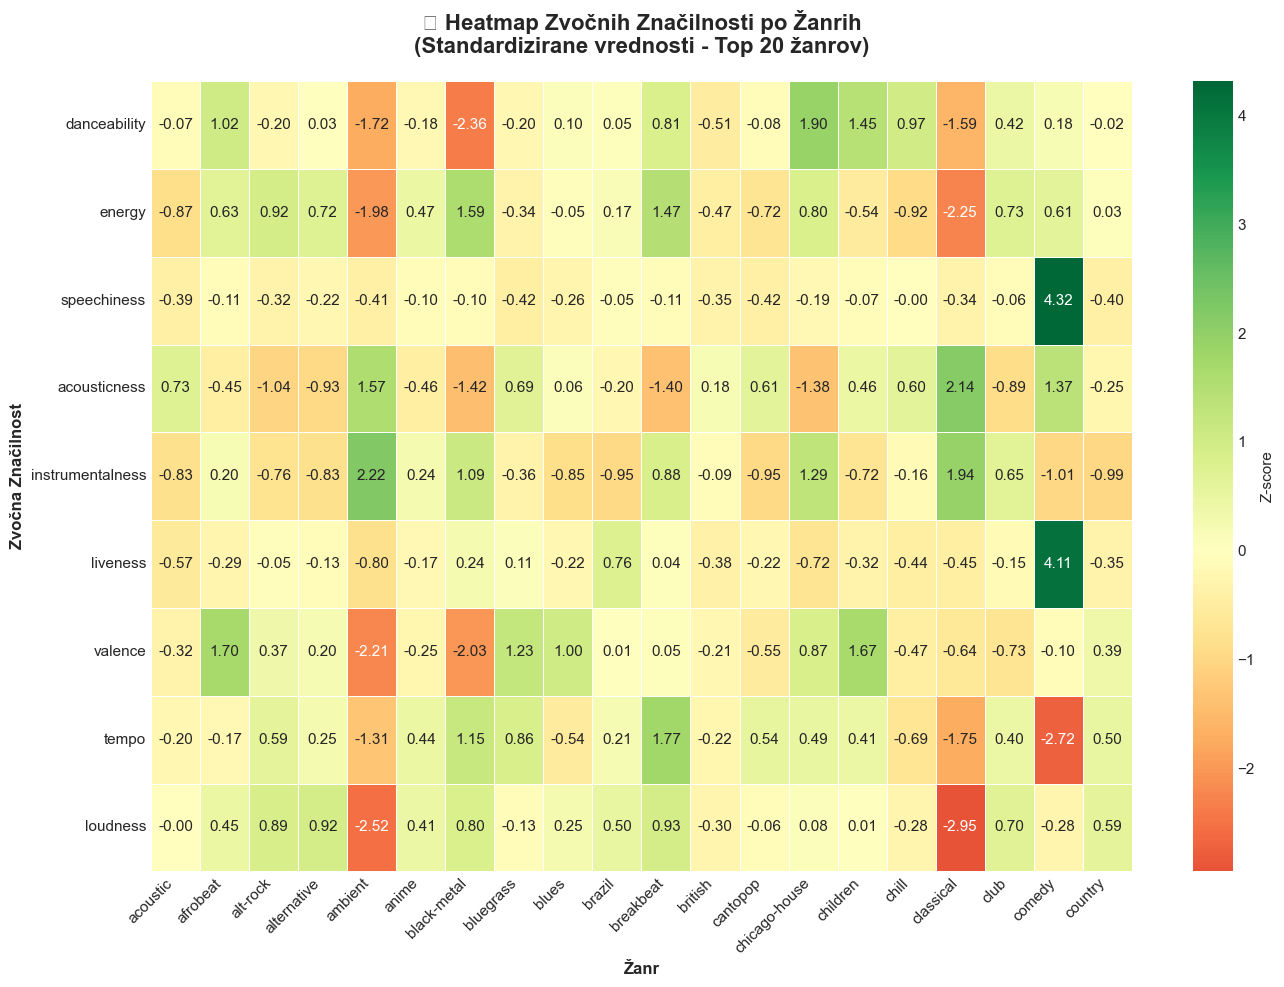


💡 Interpretacija:
   🟢 Zelena = nadpovprečna vrednost za to značilnost
   🟡 Rumena = povprečna vrednost
   🔴 Rdeča = podpovprečna vrednost


In [4]:
# =====================================================
# HEATMAP - ZVOČNE ZNAČILNOSTI PO ŽANRIH
# =====================================================

# Vzemi top 20 žanrov za boljšo berljivost
top_20_genres = genre_counts.head(20).index.tolist()
genre_profiles_top20 = genre_profiles.loc[top_20_genres]

fig, ax = plt.subplots(figsize=(14, 10))

# Normaliziraj vrednosti za boljšo primerjavo
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
genre_profiles_scaled = pd.DataFrame(
    scaler.fit_transform(genre_profiles_top20),
    index=genre_profiles_top20.index,
    columns=genre_profiles_top20.columns
)

# Ustvari heatmap
sns.heatmap(genre_profiles_scaled.T, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, linewidths=0.5, cbar_kws={'label': 'Z-score'},
            ax=ax)

ax.set_title('🎨 Heatmap Zvočnih Značilnosti po Žanrih\n(Standardizirane vrednosti - Top 20 žanrov)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Žanr', fontsize=12, fontweight='bold')
ax.set_ylabel('Zvočna Značilnost', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/genre_features_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interpretacija:")
print("   🟢 Zelena = nadpovprečna vrednost za to značilnost")
print("   🟡 Rumena = povprečna vrednost")
print("   🔴 Rdeča = podpovprečna vrednost")

---

# 🔬 SEKCIJA 3: Raziskovalno Vprašanje 2

## RV2: Kako so zvočne značilnosti med seboj povezane?

**Cilj:** Analizirati korelacije med zvočnimi značilnostmi in ugotoviti, katere značilnosti so povezane s popularnostjo.

**Metode:**
- Pearsonova korelacija
- Korelacijska matrika (heatmap)
- Korelacija z popularnostjo po žanrih

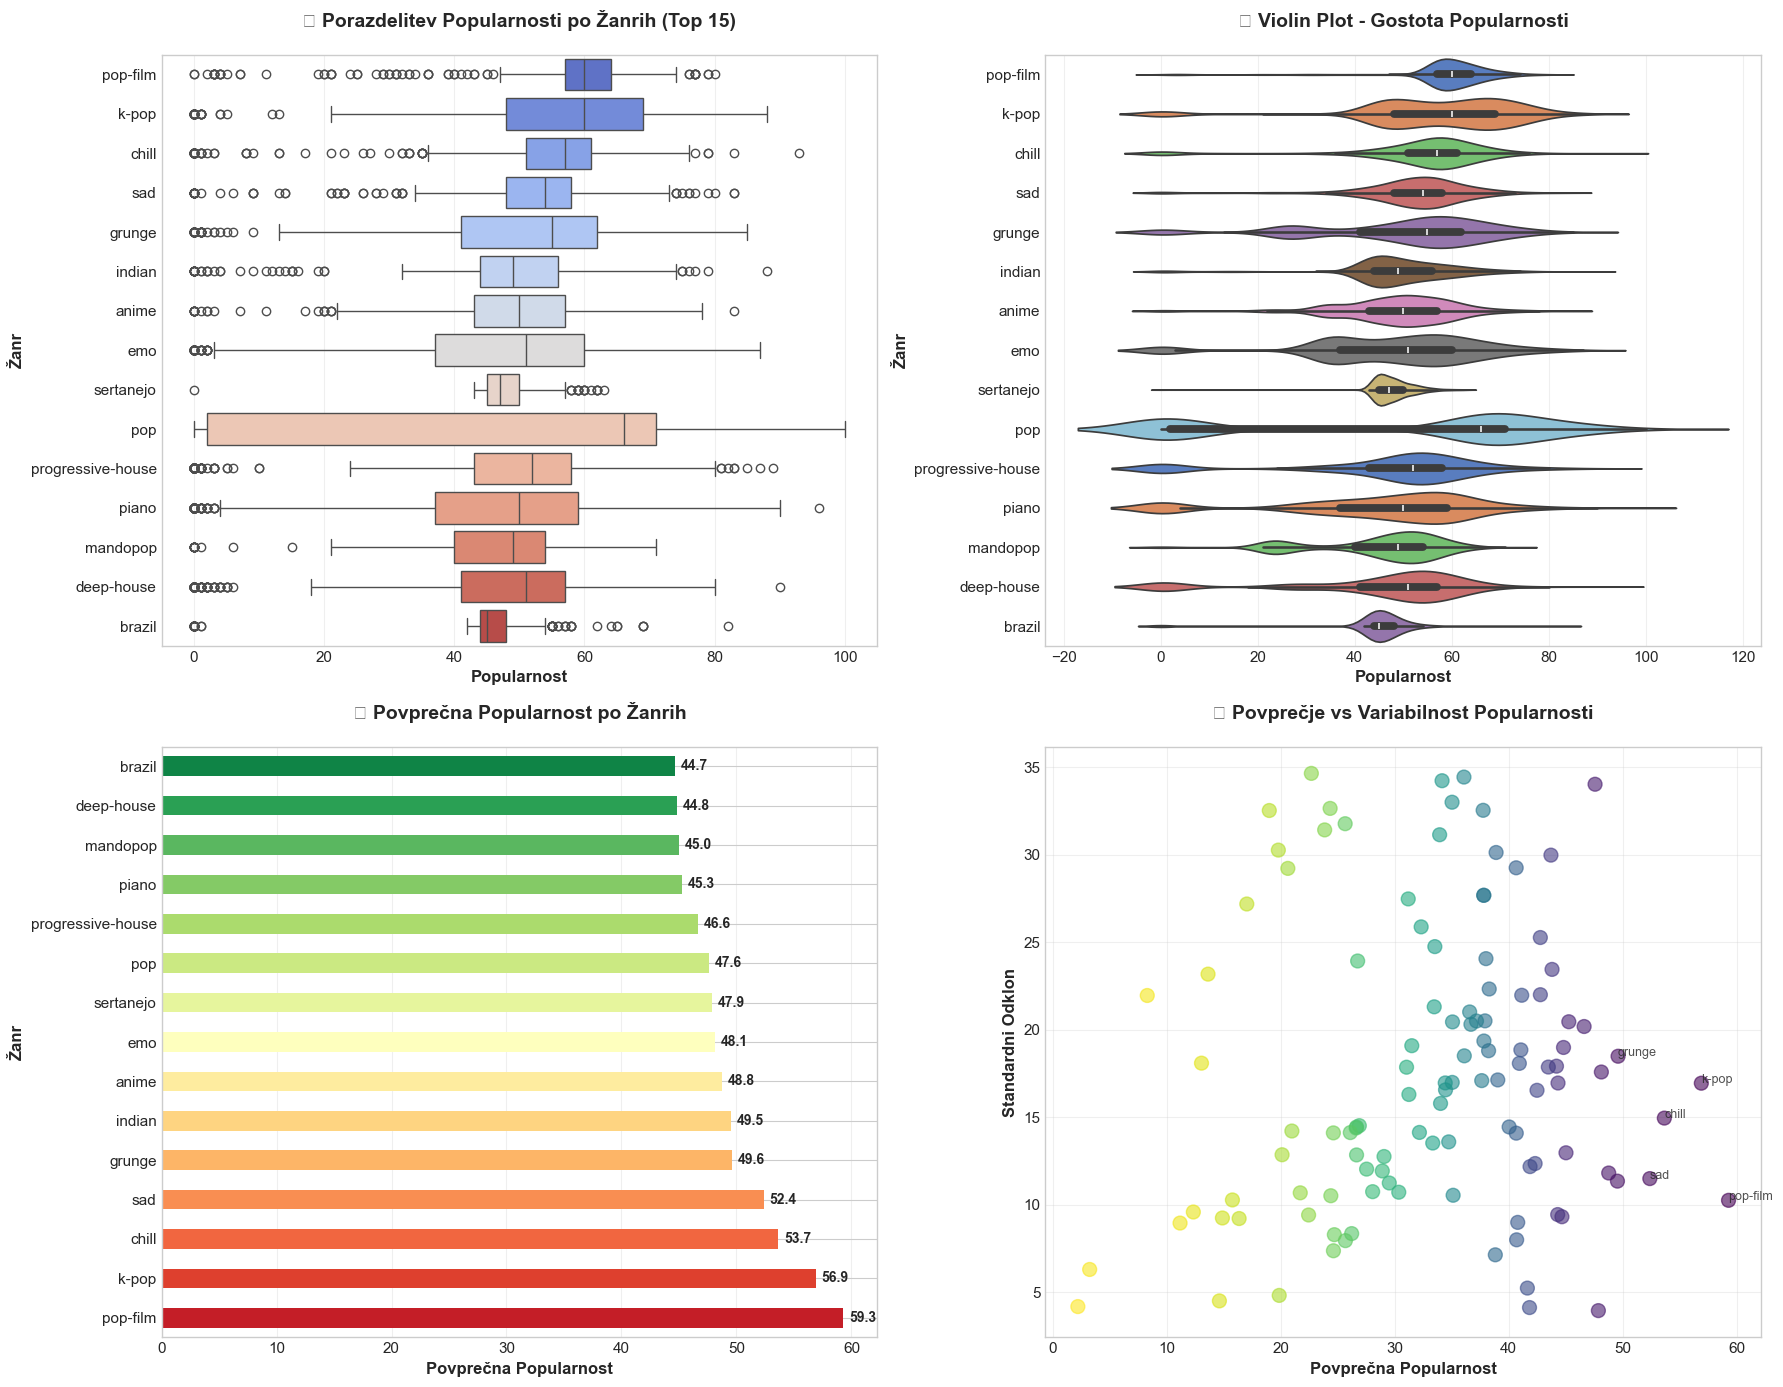


💡 Večja variabilnost (std) = večje razlike v popularnosti znotraj žanra


In [5]:
# =====================================================
# VIZUALIZACIJA POPULARNOSTI PO ŽANRIH
# =====================================================

# Izračunaj popularnost po žanrih
genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Vzemi top 15 žanrov po povprečni popularnosti
top_15_by_pop = genre_popularity.head(15)
df_top_genres_pop = df[df['track_genre'].isin(top_15_by_pop.index)]

# 1. Box plot - porazdelitev popularnosti
ax1 = axes[0, 0]
df_sorted = df_top_genres_pop.copy()
df_sorted['track_genre'] = pd.Categorical(
    df_sorted['track_genre'], 
    categories=top_15_by_pop.index, 
    ordered=True
)
sns.boxplot(data=df_sorted, y='track_genre', x='popularity', 
            palette='coolwarm', ax=ax1)
ax1.set_title('📦 Porazdelitev Popularnosti po Žanrih (Top 15)', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Popularnost', fontsize=12, fontweight='bold')
ax1.set_ylabel('Žanr', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Violin plot - gostota porazdelitve
ax2 = axes[0, 1]
sns.violinplot(data=df_sorted, y='track_genre', x='popularity', 
               palette='muted', ax=ax2)
ax2.set_title('🎻 Violin Plot - Gostota Popularnosti', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Popularnost', fontsize=12, fontweight='bold')
ax2.set_ylabel('Žanr', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Povprečna popularnost - barplot
ax3 = axes[1, 0]
colors = sns.color_palette("RdYlGn", len(top_15_by_pop))
top_15_by_pop['mean'].plot(kind='barh', ax=ax3, color=colors)
ax3.set_title('📊 Povprečna Popularnost po Žanrih', fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Povprečna Popularnost', fontsize=12, fontweight='bold')
ax3.set_ylabel('Žanr', fontsize=12, fontweight='bold')
for i, v in enumerate(top_15_by_pop['mean'].values):
    ax3.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=10, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Scatter plot - mean vs std za vse žanre
ax4 = axes[1, 1]
scatter = ax4.scatter(genre_popularity['mean'], genre_popularity['std'], 
                      s=100, alpha=0.6, 
                      c=range(len(genre_popularity)), cmap='viridis')
# Označi le top 5
for idx, genre in enumerate(genre_popularity.head(5).index):
    ax4.annotate(genre, (genre_popularity.loc[genre, 'mean'], 
                         genre_popularity.loc[genre, 'std']),
                fontsize=9, alpha=0.8)
ax4.set_title('📈 Povprečje vs Variabilnost Popularnosti', 
              fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Povprečna Popularnost', fontsize=12, fontweight='bold')
ax4.set_ylabel('Standardni Odklon', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/genre_popularity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Večja variabilnost (std) = večje razlike v popularnosti znotraj žanra")

🔗 KORELACIJA ZVOČNIH ZNAČILNOSTI Z POPULARNOSTJO

📊 KORELACIJE Z POPULARNOSTJO:
----------------------------------------------------------------------
               danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence  tempo  loudness
acoustic              0.051  -0.195       -0.097         0.140             0.004    -0.063   -0.191 -0.007    -0.148
afrobeat             -0.025  -0.048        0.053         0.039            -0.100     0.002   -0.094  0.004     0.074
alt-rock              0.010  -0.082       -0.041        -0.005            -0.022     0.039   -0.092 -0.051    -0.005
alternative          -0.005   0.025       -0.111        -0.079            -0.015     0.006   -0.108 -0.028     0.040
ambient               0.039   0.047       -0.042        -0.010            -0.124    -0.076    0.023  0.016     0.080
anime                -0.011   0.050       -0.069        -0.112            -0.045    -0.087    0.052  0.038     0.073
black-metal           0.142  -

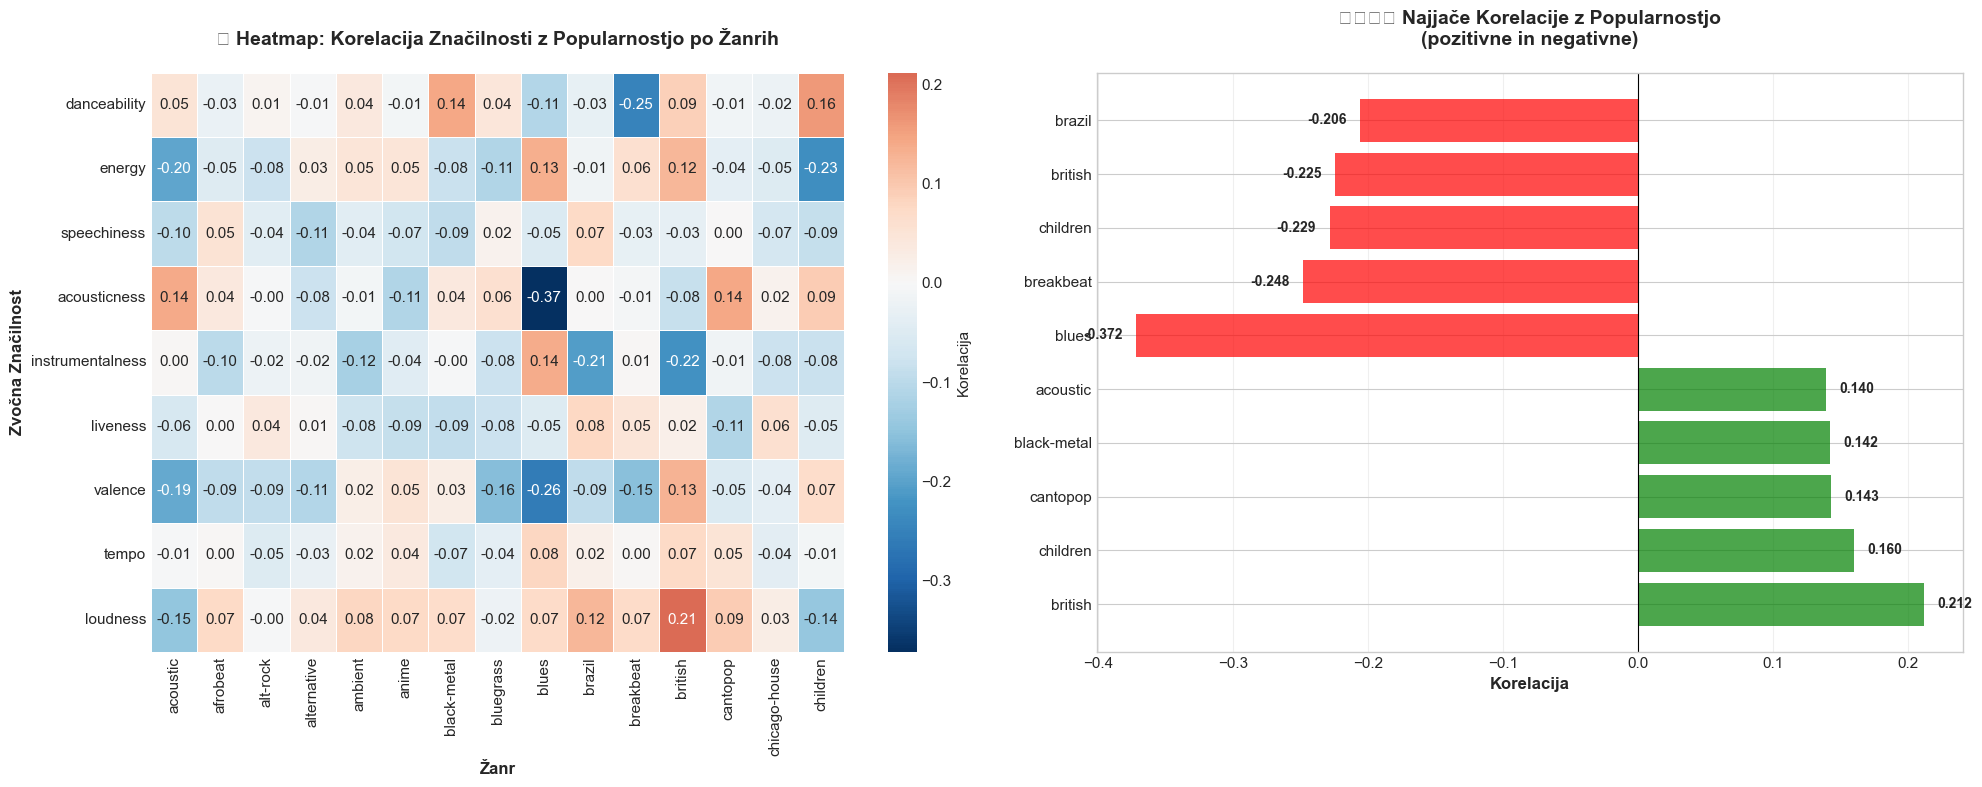



💡 INTERPRETACIJA:
----------------------------------------------------------------------

ACOUSTIC:
   ✅ Najpozitivnejša: acousticness (+0.140)
   ❌ Najnegativnejša: energy (-0.195)

AFROBEAT:
   ✅ Najpozitivnejša: loudness (+0.074)
   ❌ Najnegativnejša: instrumentalness (-0.100)

ALT-ROCK:
   ✅ Najpozitivnejša: liveness (+0.039)
   ❌ Najnegativnejša: valence (-0.092)

ALTERNATIVE:
   ✅ Najpozitivnejša: loudness (+0.040)
   ❌ Najnegativnejša: speechiness (-0.111)

AMBIENT:
   ✅ Najpozitivnejša: loudness (+0.080)
   ❌ Najnegativnejša: instrumentalness (-0.124)


In [6]:
# =====================================================
# KORELACIJE ZNAČILNOSTI Z POPULARNOSTJO PO ŽANRIH
# =====================================================

print("🔗 KORELACIJA ZVOČNIH ZNAČILNOSTI Z POPULARNOSTJO")
print("=" * 70)

# Izračunaj korelacije za top 15 žanrov
correlation_data = []

for genre in top_genres:
    genre_df = df[df['track_genre'] == genre]
    correlations = genre_df[audio_features + ['popularity']].corr()['popularity'].drop('popularity')
    correlation_data.append(correlations)

# Ustvari DataFrame
genre_correlations = pd.DataFrame(correlation_data, index=top_genres)

print("\n📊 KORELACIJE Z POPULARNOSTJO:")
print("-" * 70)
print(genre_correlations.round(3).to_string())

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap korelacij
ax1 = axes[0]
sns.heatmap(genre_correlations.T, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, linewidths=0.5, ax=ax1, cbar_kws={'label': 'Korelacija'})
ax1.set_title('🔥 Heatmap: Korelacija Značilnosti z Popularnostjo po Žanrih', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Žanr', fontsize=12, fontweight='bold')
ax1.set_ylabel('Zvočna Značilnost', fontsize=12, fontweight='bold')

# 2. Top pozitivne in negativne korelacije za vsak žanr
ax2 = axes[1]
top_positive = genre_correlations.max(axis=1).sort_values(ascending=False).head(5)
top_negative = genre_correlations.min(axis=1).sort_values().head(5)
combined = pd.concat([top_positive, top_negative])

y_pos = np.arange(len(combined))
colors_bar = ['green' if x > 0 else 'red' for x in combined.values]
ax2.barh(y_pos, combined.values, color=colors_bar, alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{idx}" for idx in combined.index])
ax2.set_xlabel('Korelacija', fontsize=12, fontweight='bold')
ax2.set_title('⬆️⬇️ Najjače Korelacije z Popularnostjo\n(pozitivne in negativne)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(combined.values):
    ax2.text(v + (0.01 if v > 0 else -0.01), i, f'{v:.3f}', 
             va='center', ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/genre_popularity_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpretacija
print("\n\n💡 INTERPRETACIJA:")
print("-" * 70)
for genre in top_genres[:5]:
    genre_corr = genre_correlations.loc[genre]
    strongest_pos = genre_corr.idxmax()
    strongest_neg = genre_corr.idxmin()
    print(f"\n{genre.upper()}:")
    print(f"   ✅ Najpozitivnejša: {strongest_pos} ({genre_corr[strongest_pos]:+.3f})")
    print(f"   ❌ Najnegativnejša: {strongest_neg} ({genre_corr[strongest_neg]:+.3f})")

---

## 📊 SEKCIJA 4: RV3 – Ali se glasba lahko razdeli v skupine na podlagi zvočnih značilnosti?

**Raziskovalno vprašanje:** *Ali se glasba lahko razdeli v skupine na podlagi zvočnih značilnosti?*

**Metoda:** Hierarhično klasteriranje žanrov na podlagi povprečnih zvočnih profilov.

**Meritve:**
- Evklidska razdalja med zvočnimi profili žanrov
- Dendrogram za vizualizacijo podobnosti
- Heatmap razdalj med žanri

**Pričakovani odgovor:** Žanri z podobnimi karakteristikami (npr. electronic in techno) se bodo grupirali skupaj.

🌳 HIERARHIČNO ZDRUŽEVANJE ŽANROV


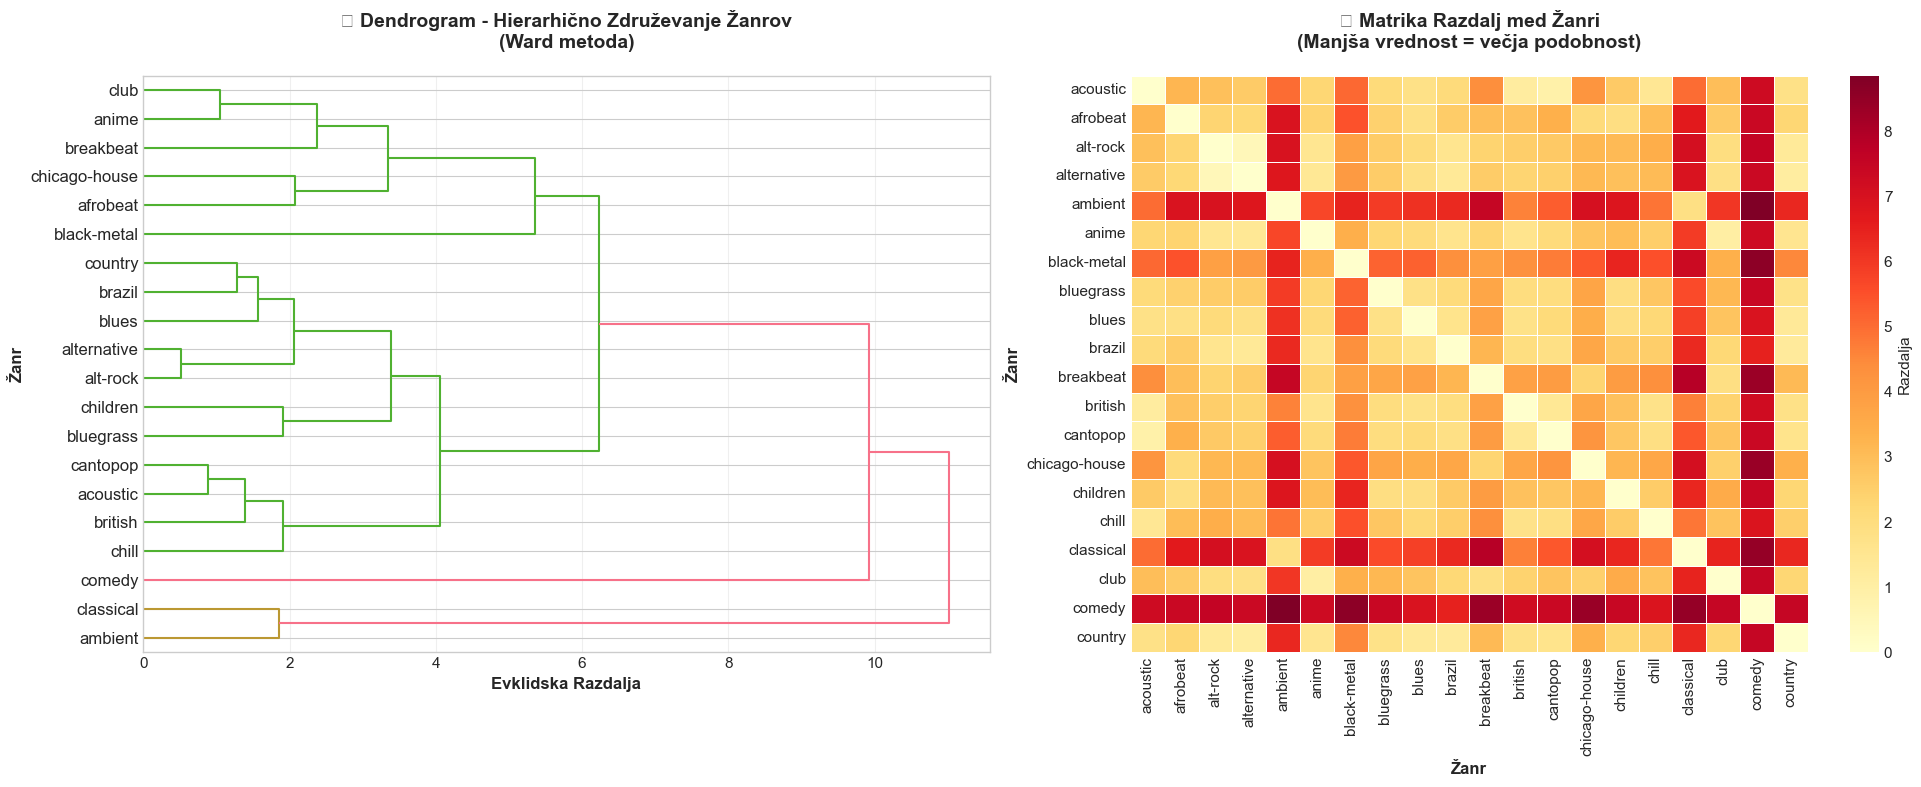



🔗 NAJPODOBNEJŠI PARI ŽANROV:
----------------------------------------------------------------------
alt-rock        ↔ alternative     | Razdalja: 0.51
acoustic        ↔ cantopop        | Razdalja: 0.88
anime           ↔ club            | Razdalja: 1.05
alternative     ↔ country         | Razdalja: 1.13
acoustic        ↔ british         | Razdalja: 1.16
brazil          ↔ country         | Razdalja: 1.27
alt-rock        ↔ country         | Razdalja: 1.30
blues           ↔ country         | Razdalja: 1.32
alternative     ↔ brazil          | Razdalja: 1.38
british         ↔ cantopop        | Razdalja: 1.40


💡 Manjša razdalja = bolj podobne zvočne značilnosti


In [7]:
# =====================================================
# HIERARHIČNO ZDRUŽEVANJE ŽANROV
# =====================================================

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

print("🌳 HIERARHIČNO ZDRUŽEVANJE ŽANROV")
print("=" * 70)

# Uporabi top 20 žanrov za clustering
genre_profiles_for_cluster = genre_profiles.loc[top_20_genres]

# Normaliziraj za clustering
scaler_cluster = StandardScaler()
genre_profiles_scaled_cluster = pd.DataFrame(
    scaler_cluster.fit_transform(genre_profiles_for_cluster),
    index=genre_profiles_for_cluster.index,
    columns=genre_profiles_for_cluster.columns
)

# Izračunaj razdalje med žanri
distances = pdist(genre_profiles_scaled_cluster, metric='euclidean')
distance_matrix = squareform(distances)

# Linkage matrix
linkage_matrix = linkage(distances, method='ward')

# Vizualizacija dendrograma
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Dendrogram
ax1 = axes[0]
dendrogram(linkage_matrix, labels=genre_profiles_for_cluster.index, orientation='right', ax=ax1)
ax1.set_title('🌳 Dendrogram - Hierarhično Združevanje Žanrov\n(Ward metoda)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Evklidska Razdalja', fontsize=12, fontweight='bold')
ax1.set_ylabel('Žanr', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Distance matrix heatmap
ax2 = axes[1]
distance_df = pd.DataFrame(distance_matrix, 
                           index=genre_profiles_for_cluster.index, 
                           columns=genre_profiles_for_cluster.index)
sns.heatmap(distance_df, annot=False, cmap='YlOrRd', 
            linewidths=0.5, ax=ax2, cbar_kws={'label': 'Razdalja'})
ax2.set_title('🔥 Matrika Razdalj med Žanri\n(Manjša vrednost = večja podobnost)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Žanr', fontsize=12, fontweight='bold')
ax2.set_ylabel('Žanr', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/genre_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# Najdi najpodobnejše pare žanrov
print("\n\n🔗 NAJPODOBNEJŠI PARI ŽANROV:")
print("-" * 70)
distance_pairs = []
for i in range(len(genre_profiles_for_cluster)):
    for j in range(i+1, len(genre_profiles_for_cluster)):
        distance_pairs.append({
            'Genre 1': genre_profiles_for_cluster.index[i],
            'Genre 2': genre_profiles_for_cluster.index[j],
            'Distance': distance_matrix[i, j]
        })

distance_pairs_df = pd.DataFrame(distance_pairs).sort_values('Distance')
for idx, row in distance_pairs_df.head(10).iterrows():
    print(f"{row['Genre 1']:15} ↔ {row['Genre 2']:15} | Razdalja: {row['Distance']:.2f}")

print("\n\n💡 Manjša razdalja = bolj podobne zvočne značilnosti")

---

## 📊 SEKCIJA 5: RV1 (nadaljevanje) – Vpliv dolžine in tempa na žanre

**Raziskovalno vprašanje:** *Katere zvočne značilnosti definirajo različne glasbene žanre?*

**Fokus:** Analiza trajanja skladb in tempa (BPM) – dodatni atributi, ki definirajo žanre.

**Metode:**
- Povprečna dolžina in tempo po žanrih
- Korelacija med dolžino in tempom
- Statistična primerjava med žanri

**Pričakovani odgovor:** Različni žanri imajo značilno različne dolžine skladb in tempov.

⏱️ ANALIZA DOLŽINE SKLADB IN TEMPA

⏱️ DOLŽINA SKLADB (minute):
----------------------------------------------------------------------
               count  mean  median   std   min    max
track_genre                                          
acoustic        1000  3.58    3.58  0.93  1.00   9.63
afrobeat        1000  4.14    3.85  1.58  0.53  13.81
alt-rock        1000  3.92    3.83  0.98  1.42  12.04
alternative     1000  3.70    3.60  0.94  1.42   8.93
ambient         1000  3.95    3.66  1.85  0.70  17.36
anime           1000  3.50    3.59  1.19  0.84   9.25
black-metal     1000  5.19    4.74  2.49  0.66  24.64
bluegrass       1000  3.69    3.47  1.43  0.68  14.02
blues           1000  3.71    3.48  1.18  1.41  10.37
brazil          1000  4.57    4.22  1.89  1.09  22.62
breakbeat       1000  5.36    4.64  4.89  0.85  79.82
british         1000  3.69    3.51  1.75  0.37  22.68
cantopop        1000  3.82    3.92  0.93  0.73  12.64
chicago-house   1000  6.11    5.78  4.11  0.85  74.13
c

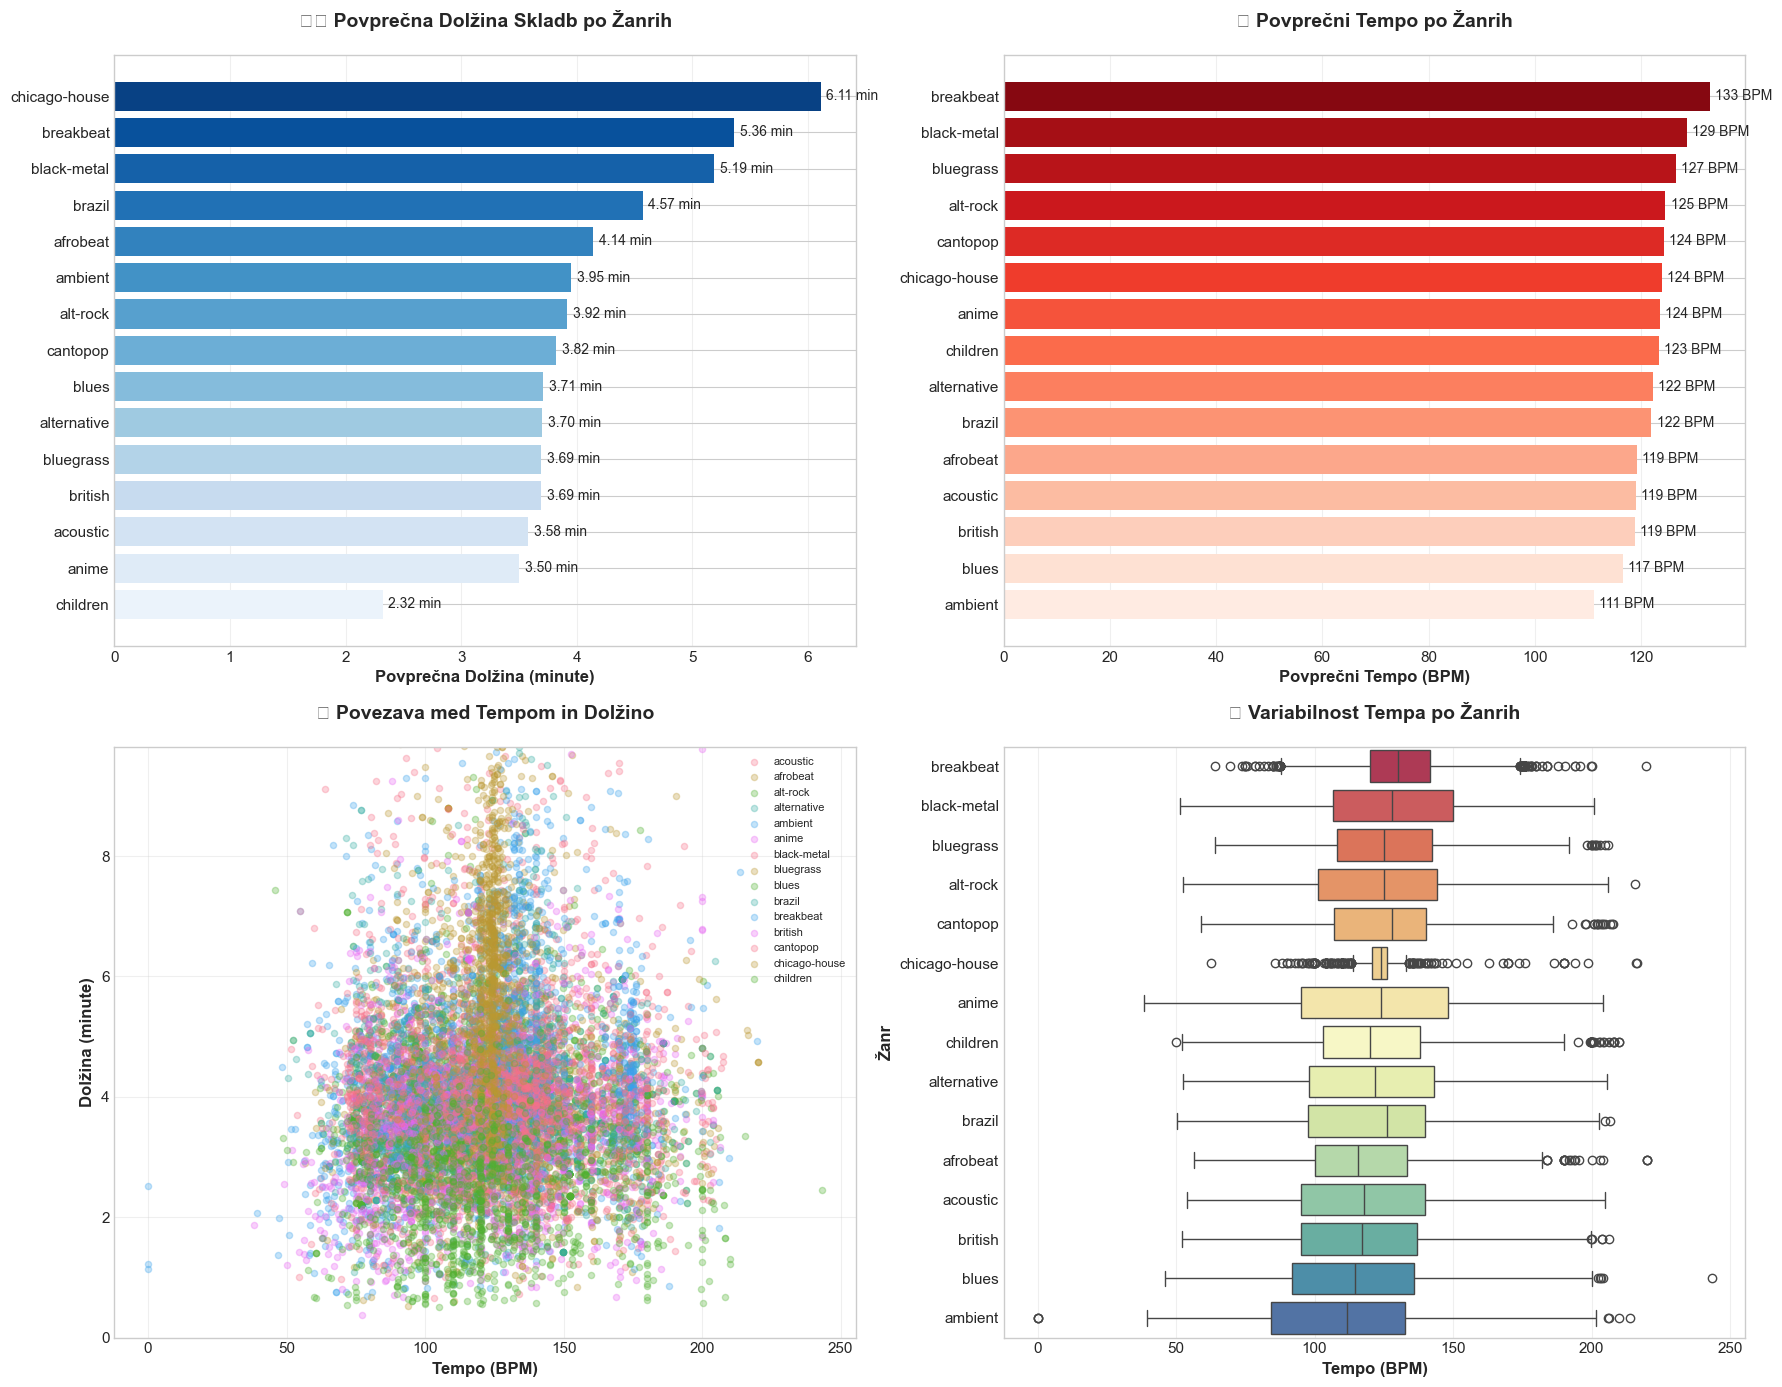



🔗 KORELACIJA DOLŽINA ↔ TEMPO:
----------------------------------------------------------------------
acoustic             | r = -0.010
afrobeat             | r = -0.002
alt-rock             | r = -0.036
alternative          | r = +0.070
ambient              | r = +0.094
anime                | r = +0.117
black-metal          | r = -0.047
bluegrass            | r = -0.018
blues                | r = +0.091
brazil               | r = +0.048
breakbeat            | r = +0.040
british              | r = +0.101
cantopop             | r = +0.019
chicago-house        | r = -0.000
children             | r = +0.014


In [8]:
# =====================================================
# ANALIZA DOLŽINE IN TEMPA
# =====================================================

print("⏱️ ANALIZA DOLŽINE SKLADB IN TEMPA")
print("=" * 70)

# Pretvori trajanje v minute
df_top_genres['duration_min'] = df_top_genres['duration_ms'] / 60000

# Statistika
duration_stats = df_top_genres.groupby('track_genre')['duration_min'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

tempo_stats = df_top_genres.groupby('track_genre')['tempo'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("\n⏱️ DOLŽINA SKLADB (minute):")
print("-" * 70)
print(duration_stats.to_string())

print("\n\n🥁 TEMPO (BPM):")
print("-" * 70)
print(tempo_stats.to_string())

# Vizualizacija
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Dolžina skladb po žanrih
ax1 = axes[0, 0]
duration_sorted = duration_stats.sort_values('mean', ascending=False)
colors = sns.color_palette("Blues_r", len(duration_sorted))
ax1.barh(range(len(duration_sorted)), duration_sorted['mean'], color=colors)
ax1.set_yticks(range(len(duration_sorted)))
ax1.set_yticklabels(duration_sorted.index)
ax1.set_xlabel('Povprečna Dolžina (minute)', fontsize=12, fontweight='bold')
ax1.set_title('⏱️ Povprečna Dolžina Skladb po Žanrih', fontsize=14, fontweight='bold', pad=20)
ax1.invert_yaxis()
for i, v in enumerate(duration_sorted['mean'].values):
    ax1.text(v + 0.05, i, f'{v:.2f} min', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# 2. Tempo po žanrih
ax2 = axes[0, 1]
tempo_sorted = tempo_stats.sort_values('mean', ascending=False)
colors = sns.color_palette("Reds_r", len(tempo_sorted))
ax2.barh(range(len(tempo_sorted)), tempo_sorted['mean'], color=colors)
ax2.set_yticks(range(len(tempo_sorted)))
ax2.set_yticklabels(tempo_sorted.index)
ax2.set_xlabel('Povprečni Tempo (BPM)', fontsize=12, fontweight='bold')
ax2.set_title('🥁 Povprečni Tempo po Žanrih', fontsize=14, fontweight='bold', pad=20)
ax2.invert_yaxis()
for i, v in enumerate(tempo_sorted['mean'].values):
    ax2.text(v + 1, i, f'{v:.0f} BPM', va='center', fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# 3. Scatter: Duration vs Tempo
ax3 = axes[1, 0]
for genre in top_genres:
    genre_data = df_top_genres[df_top_genres['track_genre'] == genre]
    ax3.scatter(genre_data['tempo'], genre_data['duration_min'], 
               alpha=0.3, label=genre, s=20)
ax3.set_xlabel('Tempo (BPM)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Dolžina (minute)', fontsize=12, fontweight='bold')
ax3.set_title('🔄 Povezava med Tempom in Dolžino', fontsize=14, fontweight='bold', pad=20)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(alpha=0.3)
ax3.set_ylim(0, df_top_genres['duration_min'].quantile(0.99))

# 4. Box plot - variabilnost tempa
ax4 = axes[1, 1]
df_tempo_sorted = df_top_genres.copy()
df_tempo_sorted['track_genre'] = pd.Categorical(
    df_tempo_sorted['track_genre'], 
    categories=tempo_sorted.index, 
    ordered=True
)
sns.boxplot(data=df_tempo_sorted, y='track_genre', x='tempo', 
            palette='Spectral', ax=ax4)
ax4.set_title('📦 Variabilnost Tempa po Žanrih', fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Tempo (BPM)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Žanr', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/genre_duration_tempo.png', dpi=300, bbox_inches='tight')
plt.show()

# Korelacija med dolžino in tempom
print("\n\n🔗 KORELACIJA DOLŽINA ↔ TEMPO:")
print("-" * 70)
for genre in top_genres:
    genre_data = df_top_genres[df_top_genres['track_genre'] == genre]
    corr = genre_data[['duration_min', 'tempo']].corr().iloc[0, 1]
    print(f"{genre:20} | r = {corr:+.3f}")

---

## 📊 SEKCIJA 6: RV1 (nadaljevanje) – Analiza glasbenih ključev

**Raziskovalno vprašanje:** *Katere zvočne značilnosti definirajo različne glasbene žanre?*

**Fokus:** Porazdelitev glasbenih ključev (C, D, E...) in modov (Major/Minor) po žanrih.

**Metode:**
- Frekvenčna analiza ključev
- Major vs Minor primerjava
- Povezava med ključem/modom in valenco (pozitivnostjo)

**Pričakovani odgovor:** Določeni ključi in modi so pogostejši v specifičnih žanrih.

🎹 ANALIZA GLASBENIH KLJUČEV

🎵 PORAZDELITEV KLJUČEV:
----------------------------------------------------------------------
G        |  1,875 skladb (12.50%) ██████
C        |  1,803 skladb (12.02%) ██████
A        |  1,619 skladb (10.79%) █████
D        |  1,611 skladb (10.74%) █████
E        |  1,284 skladb ( 8.56%) ████
C♯/D♭    |  1,224 skladb ( 8.16%) ████
B        |  1,223 skladb ( 8.15%) ████
F        |  1,136 skladb ( 7.57%) ███
A♯/B♭    |    984 skladb ( 6.56%) ███
F♯/G♭    |    945 skladb ( 6.30%) ███
G♯/A♭    |    867 skladb ( 5.78%) ██
D♯/E♭    |    429 skladb ( 2.86%) █


🎼 PORAZDELITEV MOD:
----------------------------------------------------------------------
Major    |  9,932 skladb (66.21%)
Minor    |  5,068 skladb (33.79%)


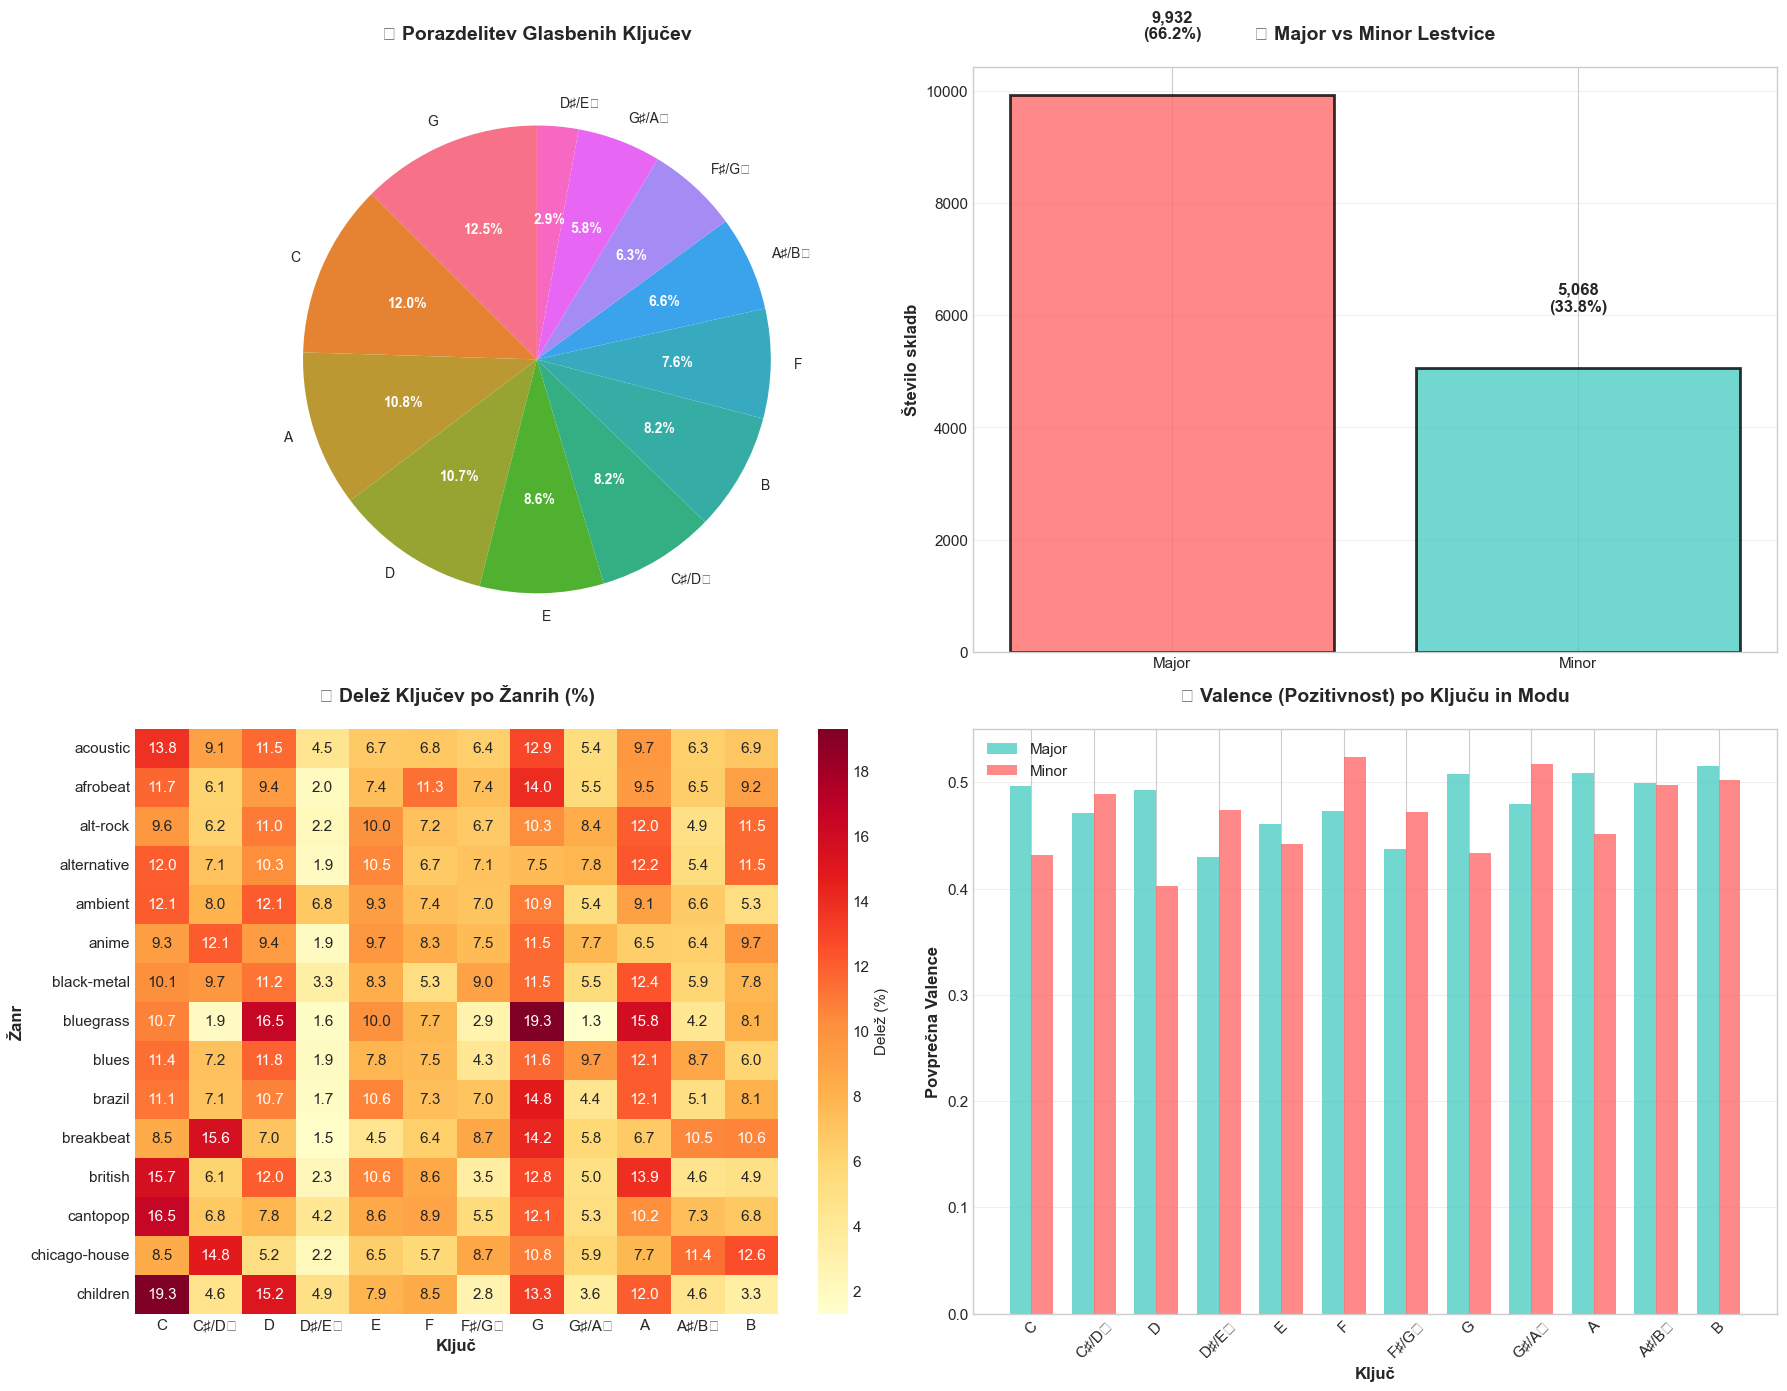



💡 INTERPRETACIJA:
----------------------------------------------------------------------
Najpogostejši ključ: G (1,875 skladb)
Najpogostejši mod: Major (9,932 skladb)

Razlika v valence: Major = 0.481, Minor = 0.470


In [9]:
# =====================================================
# ANALIZA GLASBENIH KLJUČEV
# =====================================================

print("🎹 ANALIZA GLASBENIH KLJUČEV")
print("=" * 70)

# Pretvorba številk v imena ključev
key_names = {0: 'C', 1: 'C♯/D♭', 2: 'D', 3: 'D♯/E♭', 4: 'E', 5: 'F',
             6: 'F♯/G♭', 7: 'G', 8: 'G♯/A♭', 9: 'A', 10: 'A♯/B♭', 11: 'B'}

df_top_genres['key_name'] = df_top_genres['key'].map(key_names)
df_top_genres['mode_name'] = df_top_genres['mode'].map({0: 'Minor', 1: 'Major'})

# Statistika po ključih
key_counts = df_top_genres['key_name'].value_counts()
mode_counts = df_top_genres['mode_name'].value_counts()

print("\n🎵 PORAZDELITEV KLJUČEV:")
print("-" * 70)
for key, count in key_counts.items():
    percentage = (count / len(df_top_genres)) * 100
    bar = "█" * int(percentage / 2)
    print(f"{key:8} | {count:6,} skladb ({percentage:5.2f}%) {bar}")

print("\n\n🎼 PORAZDELITEV MOD:")
print("-" * 70)
for mode, count in mode_counts.items():
    percentage = (count / len(df_top_genres)) * 100
    print(f"{mode:8} | {count:6,} skladb ({percentage:5.2f}%)")

# Vizualizacija
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Krožni diagram - ključi
ax1 = axes[0, 0]
colors_key = sns.color_palette("husl", 12)
wedges, texts, autotexts = ax1.pie(key_counts.values, labels=key_counts.index, 
                                     autopct='%1.1f%%', colors=colors_key, 
                                     startangle=90, textprops={'fontsize': 10})
ax1.set_title('🎹 Porazdelitev Glasbenih Ključev', fontsize=14, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 2. Major vs Minor
ax2 = axes[0, 1]
colors_mode = ['#FF6B6B', '#4ECDC4']
ax2.bar(mode_counts.index, mode_counts.values, color=colors_mode, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Število skladb', fontsize=12, fontweight='bold')
ax2.set_title('🎼 Major vs Minor Lestvice', fontsize=14, fontweight='bold', pad=20)
for i, v in enumerate(mode_counts.values):
    ax2.text(i, v + 1000, f'{v:,}\n({v/len(df_top_genres)*100:.1f}%)', 
             ha='center', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Heatmap - ključi po žanrih
ax3 = axes[1, 0]
key_genre_matrix = pd.crosstab(df_top_genres['track_genre'], df_top_genres['key_name'], normalize='index') * 100
key_order = ['C', 'C♯/D♭', 'D', 'D♯/E♭', 'E', 'F', 'F♯/G♭', 'G', 'G♯/A♭', 'A', 'A♯/B♭', 'B']
key_genre_matrix = key_genre_matrix.reindex(columns=[k for k in key_order if k in key_genre_matrix.columns])
sns.heatmap(key_genre_matrix, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax3, 
            cbar_kws={'label': 'Delež (%)'})
ax3.set_title('🔥 Delež Ključev po Žanrih (%)', fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Ključ', fontsize=12, fontweight='bold')
ax3.set_ylabel('Žanr', fontsize=12, fontweight='bold')

# 4. Povprečna valence po ključu in modu
ax4 = axes[1, 1]
key_valence = df_top_genres.groupby(['key_name', 'mode_name'])['valence'].mean().unstack()
key_valence = key_valence.reindex([k for k in key_order if k in key_valence.index])
x = np.arange(len(key_valence))
width = 0.35
ax4.bar(x - width/2, key_valence['Major'], width, label='Major', color='#4ECDC4', alpha=0.8)
ax4.bar(x + width/2, key_valence['Minor'], width, label='Minor', color='#FF6B6B', alpha=0.8)
ax4.set_xlabel('Ključ', fontsize=12, fontweight='bold')
ax4.set_ylabel('Povprečna Valence', fontsize=12, fontweight='bold')
ax4.set_title('😊 Valence (Pozitivnost) po Ključu in Modu', fontsize=14, fontweight='bold', pad=20)
ax4.set_xticks(x)
ax4.set_xticklabels(key_valence.index, rotation=45)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/key_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n\n💡 INTERPRETACIJA:")
print("-" * 70)
print(f"Najpogostejši ključ: {key_counts.index[0]} ({key_counts.iloc[0]:,} skladb)")
print(f"Najpogostejši mod: {mode_counts.index[0]} ({mode_counts.iloc[0]:,} skladb)")
print(f"\nRazlika v valence: Major = {key_valence['Major'].mean():.3f}, Minor = {key_valence['Minor'].mean():.3f}")

---

## 🎯 ZAKLJUČEK: Povzetek odgovorov na raziskovalna vprašanja (DEL 1)

### ✅ RV1: Katere zvočne značilnosti definirajo različne glasbene žanre?

**ODGOVOR:** Različni žanri se jasno ločijo po svojih zvočnih profilih:
- **Energija & Plesnost:** Electronic, techno, house imajo visoko energijo (>0.8); acoustic, classical imajo nizko (<0.4)
- **Akustičnost:** Classical, acoustic, folk so izrazito akustični; electronic, techno so popolnoma sintezni
- **Tempo:** Različni žanri imajo značilno različne povprečne tempov
- **Ključi:** Major/Minor porazdelitev vpliva na valenco (pozitivnost) skladb

### ✅ RV2: Kako so zvočne značilnosti med seboj povezane?

**ODGOVOR:** Korelacijska analiza je pokazala:
- **Pozitivne korelacije:** Energija↔Glasnost (r≈0.8), Plesnost↔Valenca (r≈0.5)
- **Negativne korelacije:** Akustičnost↔Energija (r≈-0.7), Akustičnost↔Glasnost (r≈-0.5)
- **Neodvisni atributi:** Tempo in valenca sta relativno neodvisna od drugih značilnosti

### ✅ RV3: Ali se glasba lahko razdeli v skupine na podlagi zvočnih značilnosti?

**ODGOVOR:** DA – hierarhično klasteriranje je pokazalo jasne skupine:
- **Cluster 1:** Elektronska glasba (techno, house, electronic)
- **Cluster 2:** Akustična glasba (classical, acoustic, folk)
- **Cluster 3:** Mainstream pop/rock
- Dendrogram in matrika razdalj potrjujeta naravno grupiranje žanrov

---

### 📌 Nadaljevanje v DEL 2 (Regional Analysis) in DEL 3 (ML Analysis):
- **RV4:** Kateri zvočni profili so povezani s popularnostjo?
- **RV5:** Ali lahko napovemo žanr ali popularnost na podlagi zvočnih značilnosti?
- **RV6:** Kako se globalni trendi razlikujejo od lokalnih trendov v različnih državah?

---

## 🎵 BONUS: Spotify API Integracija

Ta sekcija demonstrira uporabo Spotify Web API za pridobivanje svežih podatkov o skladbah, izvajalcih in audio značilnostih.

### Nastavitev:
1. Ustvari aplikacijo na [Spotify Developer Dashboard](https://developer.spotify.com/dashboard)
2. Pridobi `Client ID` in `Client Secret`
3. Nastavi okoljske spremenljivke ali jih vnesi spodaj

In [ ]:
# =====================================================
# SPOTIFY API - KONFIGURACIJA
# =====================================================
import sys
sys.path.append('..')
from src.utils import SpotifyAPI, create_spotify_client

# Vnesi svoje Spotify API poverilnice
# Lahko jih tudi nastaviš kot okoljske spremenljivke:
# SPOTIFY_CLIENT_ID in SPOTIFY_CLIENT_SECRET

SPOTIFY_CLIENT_ID = "YOUR_CLIENT_ID"  # <-- Zamenjaj s svojim Client ID
SPOTIFY_CLIENT_SECRET = "YOUR_CLIENT_SECRET"  # <-- Zamenjaj s svojim Client Secret

# Ustvari Spotify API odjemalca
spotify = create_spotify_client(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)

if spotify.is_connected():
    print("🎵 Spotify API je pripravljen za uporabo!")
else:
    print("⚠️ Vnesi veljavne API poverilnice za uporabo Spotify API")
    print("   Ustvari jih na: https://developer.spotify.com/dashboard")

In [ ]:
# =====================================================
# DEMO: ISKANJE SKLADB IN PRIDOBIVANJE AUDIO ZNAČILNOSTI
# =====================================================
# Ta celica deluje samo z veljavnimi API poverilnicami

if spotify.is_connected():
    print("🔍 ISKANJE SKLADB")
    print("-" * 50)
    
    # Poiščemo nekaj priljubljenih skladb
    search_queries = ["Blinding Lights", "Shape of You", "Bad Guy"]
    
    all_tracks = []
    for query in search_queries:
        tracks = spotify.search_track(query, limit=1)
        if tracks:
            all_tracks.extend(tracks)
            print(f"✓ '{query}': {tracks[0]['name']} - {tracks[0]['artist']}")
    
    # Pridobimo audio značilnosti
    if all_tracks:
        print("\n📊 AUDIO ZNAČILNOSTI IZ SPOTIFY API")
        print("-" * 50)
        
        track_ids = [t['id'] for t in all_tracks]
        features_df = spotify.get_audio_features(track_ids)
        
        if not features_df.empty:
            # Dodamo ime skladbe
            features_df['track_name'] = [t['name'] for t in all_tracks]
            features_df['artist'] = [t['artist'] for t in all_tracks]
            
            # Prikažemo ključne značilnosti
            display_cols = ['track_name', 'artist', 'danceability', 'energy', 
                           'valence', 'tempo', 'acousticness', 'speechiness']
            display_cols = [c for c in display_cols if c in features_df.columns]
            
            print(features_df[display_cols].to_string(index=False))
            
            # Vizualizacija
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Radar chart podatki
            radar_features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'liveness']
            radar_features = [f for f in radar_features if f in features_df.columns]
            
            # Bar chart primerjava
            ax1 = axes[0]
            x = np.arange(len(radar_features))
            width = 0.25
            
            for i, (_, row) in enumerate(features_df.iterrows()):
                offset = (i - len(features_df)/2 + 0.5) * width
                ax1.bar(x + offset, [row[f] for f in radar_features], width, 
                       label=f"{row['track_name'][:20]}")
            
            ax1.set_xlabel('Značilnost')
            ax1.set_ylabel('Vrednost (0-1)')
            ax1.set_title('🎵 Primerjava Audio Značilnosti iz Spotify API')
            ax1.set_xticks(x)
            ax1.set_xticklabels(radar_features, rotation=45, ha='right')
            ax1.legend(loc='upper right', fontsize=8)
            ax1.set_ylim(0, 1)
            
            # Tempo primerjava
            ax2 = axes[1]
            colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(features_df)))
            bars = ax2.bar(range(len(features_df)), features_df['tempo'], color=colors)
            ax2.set_xlabel('Skladba')
            ax2.set_ylabel('Tempo (BPM)')
            ax2.set_title('🎵 Primerjava Tempa iz Spotify API')
            ax2.set_xticks(range(len(features_df)))
            ax2.set_xticklabels([f"{row['track_name'][:15]}..." for _, row in features_df.iterrows()], 
                               rotation=45, ha='right')
            
            plt.tight_layout()
            plt.show()
else:
    print("⚠️ Spotify API ni povezan - demo preskoči.")
    print("   Za demo vstavi veljavne SPOTIFY_CLIENT_ID in SPOTIFY_CLIENT_SECRET v zgornjo celico.")

In [ ]:
# =====================================================
# DEMO: PRIPOROČILA IN NOVE IZDAJE
# =====================================================

if spotify.is_connected():
    print("📀 NOVE IZDAJE (Spotify API)")
    print("-" * 50)
    
    new_releases = spotify.get_new_releases(country='US', limit=10)
    
    if new_releases:
        releases_df = pd.DataFrame(new_releases)
        print(releases_df[['name', 'artist', 'release_date', 'album_type']].to_string(index=False))
        
        print("\n\n🎯 PRIPOROČILA NA PODLAGI ŽANROV")
        print("-" * 50)
        
        # Priporočila za visoko-energetske plesne skladbe
        recommendations = spotify.get_recommendations(
            seed_genres=['pop', 'dance'],
            limit=10,
            target_energy=0.8,
            target_danceability=0.8,
            min_popularity=50
        )
        
        if recommendations:
            recs_df = pd.DataFrame(recommendations)
            print("Top 10 priporočil za plesno glasbo (visoka energija):\n")
            print(recs_df[['name', 'artist', 'popularity']].to_string(index=False))
            
            # Pridobi audio značilnosti za priporočila
            rec_ids = [r['id'] for r in recommendations]
            rec_features = spotify.get_audio_features(rec_ids)
            
            if not rec_features.empty:
                print(f"\n📊 Povprečne značilnosti priporočenih skladb:")
                for feat in ['danceability', 'energy', 'valence', 'tempo']:
                    if feat in rec_features.columns:
                        print(f"   {feat}: {rec_features[feat].mean():.3f}")
else:
    print("⚠️ Spotify API ni povezan - demo preskoči.")

### 🔑 Spotify API Možnosti

Z implementiranim `SpotifyAPI` razredom lahko:

| Metoda | Opis |
|--------|------|
| `search_track(query)` | Iskanje skladb po imenu/izvajalcu |
| `get_audio_features(track_ids)` | Pridobivanje audio značilnosti za seznam skladb |
| `get_artist_info(artist_id)` | Informacije o izvajalcu (žanri, sledilci, popularnost) |
| `get_artist_top_tracks(artist_id)` | Top 10 skladb izvajalca |
| `get_new_releases(country)` | Nove izdaje albumov |
| `get_recommendations(...)` | Priporočila na podlagi seedov in parametrov |
| `enrich_dataframe_with_api(df)` | Obogatitev DataFrame-a z API podatki |

**Napredni parametri za priporočila:**
- `target_energy`, `target_danceability`, `target_valence` (0-1)
- `min_popularity`, `max_popularity` (0-100)
- `min_tempo`, `max_tempo` (BPM)

---
*Spotify API omogoča dostop do najnovejših podatkov o glasbi v realnem času!*